# EEG_34 — Il ceiling in bit: stima informazione-teorica $I(\text{EEG};\,\text{parola})$

**Domanda.** La tesi ripete ovunque che *"$\varepsilon^2(\text{parola}) = 0.03$ è il bottleneck"*. Finora è
un'affermazione **qualitativa**. Questo notebook la trasforma in un **numero**: stima la mutua
informazione $I(\text{EEG};\,\text{classe concr4})$ in **bit**, poi via **disuguaglianza di Fano**
ricava l'**accuracy massima teorica** raggiungibile su 4 classi, e la confronta con il **~34% empirico**
(soffitto DHSLP subject-specific, P007) e con il **25% di chance**.

**Perché è importante.**
- Se $\text{bound}_{\text{Fano}} \approx \text{empirico}$ → il modello è **già al ceiling informativo del dato**:
  non è il modello il limite, è l'informazione presente nel segnale. Prova **formale** di un problema
  *data-limited*, non *model-limited*.
- Se $\text{bound}_{\text{Fano}} \gg \text{empirico}$ → c'è informazione che il modello **non estrae**, e
  vale la pena cercare architetture migliori. Apre una direzione.

È il salto di rigore che distingue *"abbiamo provato tante cose e non va"* da *"abbiamo quantificato il
limite informativo e dimostrato di averlo raggiunto"*.

**Metodo — due stimatori indipendenti per robustezza:**
1. **Stimatore 1 (non-parametrico)** — `mutual_info_classif` di scikit-learn (kNN/Kraskov) tra feature e label.
2. **Stimatore 2 (MINE)** — Mutual Information Neural Estimation (Belghazi 2018): rete statistica $T(x,y)$
   che stima un **lower bound** di $I$. Con logging W&B della stima durante il training.

Poi **Fano** converte i bit in un upper bound sull'accuracy.

> ⚠️ **Esecuzione sul server** (`daniele_311`, porta 8889): checkpoint DHSLP (`models/eeg13b/`) e dati
> (`data/hypergraphs_pruned_abs_pcc/`) sono server-side. Il notebook **degrada con messaggi chiari** se
> mancano: gli stimatori MI girano comunque sullo spazio feature di controllo (band-power), e c'è un
> **fallback sintetico** per validare la correttezza del codice in locale.


## §1 — Setup

Header canonico del progetto (logger `eeg34`). Definiamo costanti, split subject-independent e il mapping
`word_label → cluster concr4`.

In [1]:
import json, logging, math, re, traceback
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
from tqdm.auto import tqdm

try:
    import wandb
    _HAS_WANDB = True
except Exception:
    _HAS_WANDB = False

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg34')

project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents)
                     if (p / '.git').exists()), Path.cwd())
FIG_DIR = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'project_root = {project_root}')
log.info(f'device = {device}')

# ---- CONFIG STANDARD ----
N_CHANNELS     = 61
N_SAMPLES      = 384
N_CLASSES      = 4
CLUSTER_SCHEME = 'concr4'
DATA_METRIC    = 'abs_pcc'
SFREQ          = 256.0

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

# Soffitto empirico DHSLP subject-specific (P007) e chance a 4 classi
EMPIRICAL_ACC = 0.34
CHANCE_ACC    = 1.0 / N_CLASSES

# word_label (0..109) -> cluster concr4 (0..3)
label2cluster = {int(k): int(v) for k, v in json.loads(
    (project_root / 'configs' / 'label_schemes' / 'labelid2cluster_concr4.json').read_text()).items()}
CLUSTER_NAMES = ['CONCR', 'AZIONE', 'STATO', 'ASTR']

# Split subject-independent standard (identico a EEG_13/26/29)
SUBJ_TRAIN = list(range(0, 50))
SUBJ_VAL   = list(range(50, 60))
SUBJ_TEST  = list(range(60, 74))

SEEDS = [0, 1, 2, 3, 4]   # piu' seed -> intervallo/varianza sulla stima MI
log.info('Setup completato.')


/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
15:41:19 INFO     project_root = /home/daniele_u/miralis-hypergraph-imagined-speech
15:41:19 INFO     device = cuda
15:41:19 INFO     Setup completato.


## §2 — Rappresentazioni: due spazi feature per ogni trial

Costruiamo, per ogni trial, due rappresentazioni indipendenti. La label è sempre il **cluster concr4**.

- **(a) Latente DHSLP** — carichiamo un checkpoint subject-specific (`models/eeg13b/P<NNN>.pt`) e usiamo
  `model.encode(x) → (HIDDEN=128)`. È lo spazio in cui *opera realmente* il modello: la MI qui misura
  l'informazione che il modello **rende disponibile** al suo classificatore.
- **(b) Band-power multi-banda** — spazio semplice e interpretabile (5 bande × 61 canali = 305 feature),
  usato come **controllo**: misura l'informazione *grezza* presente nel segnale, indipendente dal modello.

Confrontare i due è informativo: se la MI nel latente DHSLP $\approx$ la MI nel band-power, il modello non
sta scartando informazione; se è molto minore, il modello sta comprimendo via informazione utile.

Lavoriamo sullo split **TEST** (subject-independent) per coerenza con le altre analisi, e — se i checkpoint
ci sono — anche **per-soggetto** sui top (P007).

In [2]:
# ---- Sorgente dati: file .pt per-trial (server-side) ----
_PAT = re.compile(r'^P(\d+)_S(\d+)$')
HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'

subj_sess = defaultdict(lambda: defaultdict(list))
if HG_ROOT.exists():
    for p in sorted(HG_ROOT.rglob('trial_*.pt')):
        m = _PAT.match(p.parent.name)
        if m:
            subj_sess[int(m.group(1))][int(m.group(2))].append(p)
ALL_SUBJ = sorted(subj_sess.keys())
DATA_AVAILABLE = len(ALL_SUBJ) > 0
log.info(f'DATA_AVAILABLE={DATA_AVAILABLE} | n_subj={len(ALL_SUBJ)}')

def load_trial(p):
    '''Ritorna (x_np(61,384) float32, word_label int).'''
    d = torch.load(p, weights_only=False)
    x = d['x'].float().numpy()
    y = d['y']
    y = int(y.squeeze()) if isinstance(y, torch.Tensor) else int(y)
    return x, y

def instance_norm(x):
    '''Normalizzazione per-trial per-canale (come EEG_13b/26/29).'''
    if isinstance(x, np.ndarray):
        return (x - x.mean(1, keepdims=True)) / (x.std(1, keepdims=True) + 1e-6)
    return (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)


15:41:20 INFO     DATA_AVAILABLE=True | n_subj=74


In [3]:
# ---- (b) Band-power multi-banda: spazio feature di controllo, interpretabile ----
BANDS = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 45)}

def bandpower_features(x_np, sfreq=SFREQ):
    '''x_np (61,384) -> vettore (61*len(BANDS),) log band-power via FFT (Welch-like single window).
    Spazio semplice e interpretabile: NON e' feature engineering come soluzione, ma controllo diagnostico.'''
    x = x_np - x_np.mean(axis=1, keepdims=True)
    n = x.shape[1]
    freqs = np.fft.rfftfreq(n, d=1.0 / sfreq)
    psd = (np.abs(np.fft.rfft(x, axis=1)) ** 2) / n      # (61, n_freq)
    feats = []
    for (lo, hi) in BANDS.values():
        mask = (freqs >= lo) & (freqs < hi)
        bp = psd[:, mask].mean(axis=1) if mask.any() else np.zeros(x.shape[0])
        feats.append(np.log(bp + 1e-12))
    return np.concatenate(feats).astype(np.float32)      # (61*5,)


In [4]:
# ---- Architettura DHSLP (Li et al. 2025) per estrarre il latente .encode() ----
K_WINDOWS, N_EDGES, D_MODEL, HIDDEN, N_LAYERS, DROPOUT = 8, 16, 64, 128, 2, 0.5
T_WIN = N_SAMPLES // K_WINDOWS

class HGNNConv(nn.Module):
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)
    def forward(self, X, H):
        d_v = H.sum(dim=2).clamp(min=1e-6); d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1); De = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1, 2), out)
        out = De.transpose(1, 2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out

class DHSLP(nn.Module):
    def __init__(self, n_nodes=N_CHANNELS, T_win=T_WIN, K=K_WINDOWS, n_edges=N_EDGES,
                 d_model=D_MODEL, hidden=HIDDEN, n_classes=N_CLASSES,
                 n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.K, self.T_win, self.d_model = K, T_win, d_model
        self.E = nn.Parameter(torch.randn(n_edges, d_model) * 0.01)
        self.pos_enc = nn.Parameter(torch.randn(n_nodes, d_model) * 0.01)
        self.node_proj = nn.Sequential(nn.Linear(T_win, d_model), nn.LayerNorm(d_model), nn.ELU())
        dims = [d_model] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)
    def build_dynamic_H(self, feat):
        scores = torch.matmul(feat, self.E.T) / (self.d_model ** 0.5)
        return torch.softmax(scores, dim=2)
    def encode(self, x):
        B, N, T = x.shape
        outs = []
        for k in range(self.K):
            x_k  = x[:, :, k*self.T_win:(k+1)*self.T_win]
            feat = self.node_proj(x_k) + self.pos_enc.unsqueeze(0)
            H    = self.build_dynamic_H(feat)
            h = feat
            for conv, bn in zip(self.convs, self.bns):
                h = conv(h, H)
                h = bn(h.transpose(1, 2)).transpose(1, 2)
                h = F.elu(h); h = self.drop(h)
            outs.append(h.mean(dim=1))
        return torch.stack(outs, 0).mean(0)
    def forward(self, x):
        return self.clf(self.encode(x))


In [5]:
# ---- Estrazione rappresentazioni: latente DHSLP + band-power, su un insieme di trial ----
CKPT_DIR = project_root / 'models' / 'eeg13b'

def list_trials_for_subjects(subj_ids, max_per_subj=None):
    '''Lista (path) di tutti i trial dei soggetti dati.'''
    paths = []
    for sid in subj_ids:
        if sid not in subj_sess:
            continue
        sub = []
        for sess in sorted(subj_sess[sid]):
            sub.extend(subj_sess[sid][sess])
        if max_per_subj is not None:
            sub = sub[:max_per_subj]
        paths.extend(sub)
    return paths

def _infer_dhslp_kwargs(sd):
    '''Inferisce hidden e n_layers dallo state_dict per gestire checkpoint con architetture diverse.'''
    # hidden: dimensione del layer finale prima del classificatore
    clf_w = sd.get('clf.weight')
    hidden = int(clf_w.shape[1]) if clf_w is not None else HIDDEN
    # n_layers: quanti HGNNConv ci sono (convs.0, convs.1, ...)
    n_layers = len([k for k in sd if k.startswith('convs.') and k.endswith('.weight')])
    n_layers = max(n_layers, 1)
    return dict(hidden=hidden, n_layers=n_layers)

def load_dhslp_for_subject(sid):
    '''Carica un DHSLP S-Spec da checkpoint; None se assente.
    Inferisce l'architettura (hidden, n_layers) dal checkpoint per evitare size mismatch.'''
    fp = CKPT_DIR / f'P{sid:03d}.pt'
    if not fp.exists():
        return None
    ckpt = torch.load(fp, weights_only=False)
    sd = ckpt.get('state_dict', ckpt if isinstance(ckpt, dict) and 'E' in ckpt else None)
    if sd is None:
        log.warning(f'Checkpoint {fp.name} senza state_dict riconoscibile; salto.')
        return None
    kwargs = _infer_dhslp_kwargs(sd)
    if kwargs['hidden'] != HIDDEN or kwargs['n_layers'] != N_LAYERS:
        log.info(f'P{sid:03d}: architettura checkpoint hidden={kwargs["hidden"]} '
                 f'n_layers={kwargs["n_layers"]} (default: {HIDDEN}/{N_LAYERS})')
    model = DHSLP(**kwargs).to(device)
    try:
        model.load_state_dict(sd)
    except Exception as e:
        log.warning(f'load_state_dict strict fallita su {fp.name}: {e}. Provo strict=False.')
        model.load_state_dict(sd, strict=False)
    model.eval()
    return model

@torch.no_grad()
def encode_latent(model, paths, batch=128):
    '''Restituisce (Z (n, hidden) np, y_cluster (n,) np) usando model.encode.'''
    Z, Y = [], []
    for i in range(0, len(paths), batch):
        chunk = paths[i:i+batch]
        xs, ys = [], []
        for p in chunk:
            x, wl = load_trial(p)
            xs.append(torch.tensor(instance_norm(x)))
            ys.append(label2cluster[wl])
        xb = torch.stack(xs).float().to(device)
        z = model.encode(xb).cpu().numpy()
        Z.append(z); Y.extend(ys)
    return np.concatenate(Z, 0), np.array(Y, dtype=np.int64)

def bandpower_matrix(paths):
    '''Restituisce (X (n,305) np, y_cluster (n,) np) di band-power.'''
    X, Y = [], []
    for p in paths:
        x, wl = load_trial(p)
        X.append(bandpower_features(x)); Y.append(label2cluster[wl])
    return np.asarray(X, dtype=np.float32), np.array(Y, dtype=np.int64)

In [6]:
# ---- Costruzione effettiva delle rappresentazioni (con fallback documentato) ----
# Restituiamo un dizionario REPS: nome_spazio -> (X, y). Ogni spazio e' indipendente.
REPS = {}

if DATA_AVAILABLE:
    test_paths = list_trials_for_subjects(SUBJ_TEST)
    log.info(f'[TEST split] n_trials = {len(test_paths)}')

    # (b) band-power: sempre disponibile se ci sono i dati
    Xbp, ybp = bandpower_matrix(test_paths)
    REPS['bandpower_test'] = (Xbp, ybp)
    log.info(f'band-power TEST: X={Xbp.shape}, classi={np.bincount(ybp, minlength=N_CLASSES)}')

    # (a) latente DHSLP: dipende dai checkpoint
    any_ckpt = False
    for sid in SUBJ_TEST:
        m = load_dhslp_for_subject(sid)
        if m is not None:
            any_ckpt = True
            paths = list_trials_for_subjects([sid])
            Z, y = encode_latent(m, paths)
            REPS[f'dhslp_latent_P{sid:03d}'] = (Z, y)
            log.info(f'DHSLP latent P{sid:03d}: Z={Z.shape}')
    # Top subject P007 per-soggetto (se presente)
    m7 = load_dhslp_for_subject(7)
    if m7 is not None and 'dhslp_latent_P007' not in REPS:
        Z7, y7 = encode_latent(m7, list_trials_for_subjects([7]))
        REPS['dhslp_latent_P007'] = (Z7, y7)
    if not any_ckpt:
        log.warning('[INFO] Nessun checkpoint DHSLP trovato in models/eeg13b/. '
                    'Procedo con il solo spazio band-power di controllo.')
else:
    log.warning('[INFO] Dati .pt non disponibili in locale (server-side). '
                'Genero un dataset SINTETICO per validare la correttezza degli stimatori.')
    # Dataset sintetico: 4 gaussiane con MI nota approssimativa, per testare il codice end-to-end.
    rng = np.random.default_rng(0)
    n_per, d = 600, 32
    sep = 0.6   # separazione bassa -> MI bassa, mima il regime data-limited
    Xs, ys = [], []
    centers = rng.normal(size=(N_CLASSES, d)) * sep
    for c in range(N_CLASSES):
        Xs.append(rng.normal(size=(n_per, d)) + centers[c]); ys += [c]*n_per
    REPS['synthetic'] = (np.concatenate(Xs, 0).astype(np.float32),
                         np.array(ys, dtype=np.int64))
    log.info('Spazio sintetico pronto (solo validazione codice).')

print('Spazi feature disponibili:', list(REPS.keys()))


15:41:20 INFO     [TEST split] n_trials = 7260
15:41:26 INFO     band-power TEST: X=(7260, 305), classi=[1188 1782 1386 2904]
15:41:26 INFO     P060: architettura checkpoint hidden=64 n_layers=1 (default: 128/2)
15:41:27 INFO     DHSLP latent P060: Z=(550, 64)
15:41:27 INFO     P061: architettura checkpoint hidden=64 n_layers=1 (default: 128/2)
15:41:27 INFO     DHSLP latent P061: Z=(550, 64)
15:41:27 INFO     P062: architettura checkpoint hidden=64 n_layers=1 (default: 128/2)
15:41:27 INFO     DHSLP latent P062: Z=(550, 64)
15:41:27 INFO     P063: architettura checkpoint hidden=64 n_layers=1 (default: 128/2)
15:41:27 INFO     DHSLP latent P063: Z=(550, 64)
15:41:27 INFO     P064: architettura checkpoint hidden=64 n_layers=1 (default: 128/2)
15:41:27 INFO     DHSLP latent P064: Z=(550, 64)
15:41:27 INFO     P065: architettura checkpoint hidden=64 n_layers=1 (default: 128/2)
15:41:27 INFO     DHSLP latent P065: Z=(550, 64)
15:41:27 INFO     P066: architettura checkpoint hidden=64 n_laye

Spazi feature disponibili: ['bandpower_test', 'dhslp_latent_P060', 'dhslp_latent_P061', 'dhslp_latent_P062', 'dhslp_latent_P063', 'dhslp_latent_P064', 'dhslp_latent_P065', 'dhslp_latent_P066', 'dhslp_latent_P067', 'dhslp_latent_P068', 'dhslp_latent_P069', 'dhslp_latent_P070', 'dhslp_latent_P071', 'dhslp_latent_P072', 'dhslp_latent_P007']


## §3 — Stimatore 1: MI non-parametrica (Kraskov / kNN)

`sklearn.feature_selection.mutual_info_classif` stima $I(\text{feature}_j;\,Y)$ tra **ogni feature** e la
label discreta, con un estimatore **kNN (Kraskov-Stögbauer-Grassberger)**. L'output di sklearn è in **nat**;
moltiplichiamo per $\log_2 e$ per ottenere **bit**.

> ⚠️ **Limite dell'additività.** Sommare la MI marginale feature-per-feature **sovrastima** $I(\mathbf{X};Y)$
> quando le feature sono correlate (e in EEG lo sono molto). La somma è quindi un **upper bound ottimistico**.
> Per una stima più onesta del *vettore congiunto* riportiamo anche:
> - il **massimo** sulle feature (lower bound banale: $I(\mathbf{X};Y) \ge \max_j I(X_j;Y)$),
> - una stima **kNN diretta sul vettore** ridotto via PCA (estimatore congiunto, più conservativo).
>
> La verità sta tra `max` (lower) e `sum` (upper); usiamo entrambi per delimitare il ceiling.

In [7]:
def mi_classif_bits(X, y, n_neighbors=3, seed=0):
    '''MI marginale per-feature (bit). Ritorna array (n_features,).'''
    mi_nat = mutual_info_classif(X, y, discrete_features=False,
                                 n_neighbors=n_neighbors, random_state=seed)
    return mi_nat * np.log2(np.e)   # nat -> bit

def knn_mi_joint_bits(X, y, n_neighbors=3, n_pca=8, seed=0):
    '''Stima kNN DIRETTA di I(X_vec; Y) sul vettore congiunto, ridotto via PCA.
    Approccio: I(X;Y) = H(Y) - H(Y|X). Stimiamo H(Y|X) con un classificatore kNN
    leave-one-out sulla cross-entropy delle prob predette (proper, congiunto).'''
    from sklearn.decomposition import PCA
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import cross_val_predict
    Xs = StandardScaler().fit_transform(X)
    nc = min(n_pca, Xs.shape[1])
    Xr = PCA(n_components=nc, random_state=seed).fit_transform(Xs)
    k = max(n_neighbors, 5)
    clf = KNeighborsClassifier(n_neighbors=min(k, len(y)-1), weights='distance')
    # prob out-of-fold -> stima onesta di p(y|x)
    proba = cross_val_predict(clf, Xr, y, cv=5, method='predict_proba')
    proba = np.clip(proba, 1e-9, 1.0)
    classes = np.unique(y)
    # H(Y|X) media della cross-entropy del vero label sotto p(y|x)
    idx = {c: i for i, c in enumerate(classes)}
    ce = -np.mean([np.log2(proba[i, idx[y[i]]]) for i in range(len(y))])  # bit
    py = np.bincount(y, minlength=len(classes)) / len(y)
    py = py[py > 0]
    H_Y = -np.sum(py * np.log2(py))   # bit
    return max(H_Y - ce, 0.0), H_Y     # I(X;Y) >= 0


In [8]:
# ---- Esecuzione Stimatore 1 su ogni spazio, su piu' seed ----
def entropy_of_labels_bits(y):
    py = np.bincount(y, minlength=N_CLASSES); py = py / py.sum(); py = py[py > 0]
    return float(-np.sum(py * np.log2(py)))

est1_rows = []
for name, (X, y) in REPS.items():
    H_Y = entropy_of_labels_bits(y)
    sums, maxes, joints = [], [], []
    for s in SEEDS:
        mi = mi_classif_bits(X, y, seed=s)
        sums.append(float(mi.sum())); maxes.append(float(mi.max()))
        try:
            j, _ = knn_mi_joint_bits(X, y, seed=s)
        except Exception as e:
            log.warning(f'knn_mi_joint fallita su {name} seed{s}: {e}'); j = np.nan
        joints.append(j)
    joints = np.array(joints, dtype=float)
    est1_rows.append(dict(
        space=name, n=len(y), n_feat=X.shape[1], H_Y_bits=H_Y,
        mi_sum_bits=np.mean(sums), mi_sum_std=np.std(sums),
        mi_max_bits=np.mean(maxes),
        mi_joint_bits=np.nanmean(joints), mi_joint_std=np.nanstd(joints),
    ))
    log.info(f'[Est1] {name}: H(Y)={H_Y:.3f} bit | sum={np.mean(sums):.3f} | '
             f'max={np.mean(maxes):.3f} | joint(kNN)={np.nanmean(joints):.3f} bit')

est1_df = pd.DataFrame(est1_rows)
est1_df


15:41:47 INFO     [Est1] bandpower_test: H(Y)=1.910 bit | sum=1.297 | max=0.028 | joint(kNN)=0.000 bit
15:41:47 INFO     [Est1] dhslp_latent_P060: H(Y)=1.910 bit | sum=0.722 | max=0.065 | joint(kNN)=0.000 bit
15:41:48 INFO     [Est1] dhslp_latent_P061: H(Y)=1.910 bit | sum=1.472 | max=0.117 | joint(kNN)=0.000 bit
15:41:48 INFO     [Est1] dhslp_latent_P062: H(Y)=1.910 bit | sum=0.947 | max=0.107 | joint(kNN)=0.000 bit
15:41:49 INFO     [Est1] dhslp_latent_P063: H(Y)=1.910 bit | sum=1.129 | max=0.150 | joint(kNN)=0.000 bit
15:41:49 INFO     [Est1] dhslp_latent_P064: H(Y)=1.910 bit | sum=0.964 | max=0.097 | joint(kNN)=0.000 bit
15:41:50 INFO     [Est1] dhslp_latent_P065: H(Y)=1.910 bit | sum=0.774 | max=0.093 | joint(kNN)=0.000 bit
15:41:51 INFO     [Est1] dhslp_latent_P066: H(Y)=1.910 bit | sum=1.064 | max=0.084 | joint(kNN)=0.000 bit
15:41:51 INFO     [Est1] dhslp_latent_P067: H(Y)=1.910 bit | sum=0.941 | max=0.096 | joint(kNN)=0.000 bit
15:41:52 INFO     [Est1] dhslp_latent_P068: H(Y)=

,space,n,n_feat,H_Y_bits,mi_sum_bits,mi_sum_std,mi_max_bits,mi_joint_bits,mi_joint_std
0,bandpower_test,7260,305,1.909594,1.297163,1.384063e-04,0.028261,0.0,0.0
1,dhslp_latent_P060,550,64,1.909594,0.722462,0.000000e+00,0.064783,0.0,0.0
2,dhslp_latent_P061,550,64,1.909594,1.471611,0.000000e+00,0.116640,0.0,0.0
3,dhslp_latent_P062,550,64,1.909594,0.947373,1.110223e-16,0.106540,0.0,0.0
4,dhslp_latent_P063,550,64,1.909594,1.129058,0.000000e+00,0.149670,0.0,0.0
5,dhslp_latent_P064,550,64,1.909594,0.963763,0.000000e+00,0.097007,0.0,0.0
6,dhslp_latent_P065,550,64,1.909594,0.774083,0.000000e+00,0.092926,0.0,0.0
7,dhslp_latent_P066,550,64,1.909594,1.064198,0.000000e+00,0.083592,0.0,0.0
8,dhslp_latent_P067,550,64,1.909594,0.940967,0.000000e+00,0.095852,0.0,0.0
9,dhslp_latent_P068,550,64,1.909594,1.034620,0.000000e+00,0.105896,0.0,0.0


## §4 — Stimatore 2: MINE (Mutual Information Neural Estimation, Belghazi 2018)

MINE stima un **lower bound** di $I(X;Y)$ tramite la rappresentazione di Donsker-Varadhan:

$$I(X;Y) \;\ge\; \mathbb{E}_{p(x,y)}[T_\theta(x,y)] \;-\; \log\,\mathbb{E}_{p(x)p(y)}\big[e^{T_\theta(x,y)}\big]$$

dove $T_\theta$ è una piccola rete statistica. I campioni **congiunti** vengono dal batch reale; i campioni
**marginali** $p(x)p(y)$ si ottengono **permutando** $y$ nel batch. La label viste come **embedding**
condiziona $T$. Massimizzando il bound rispetto a $\theta$ otteniamo la stima.

Vantaggi rispetto a Est1: è un estimatore **congiunto** (non additivo), nativo in PyTorch, e logghiamo la
stima su **W&B** durante il training. Limite: è un **lower bound** e può avere varianza alta; usiamo
**EMA** del termine marginale (correzione del bias del gradiente come nel paper) e più seed.

In [9]:
class MineT(nn.Module):
    '''Rete statistica T(x, y_emb). y discreta -> embedding appreso.'''
    def __init__(self, x_dim, n_classes=N_CLASSES, y_emb=16, hidden=128):
        super().__init__()
        self.y_emb = nn.Embedding(n_classes, y_emb)
        self.net = nn.Sequential(
            nn.Linear(x_dim + y_emb, hidden), nn.ELU(),
            nn.Linear(hidden, hidden), nn.ELU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x, y):
        return self.net(torch.cat([x, self.y_emb(y)], dim=1)).squeeze(-1)

def mine_estimate(X, y, epochs=400, batch=256, lr=1e-3, ema_alpha=0.01,
                  seed=0, wandb_run=None, tag=''):
    '''Stima MINE (bit) di I(X;Y). Ritorna (mi_bits, history).'''
    torch.manual_seed(seed); np.random.seed(seed)
    Xs = StandardScaler().fit_transform(X).astype(np.float32)
    Xt = torch.tensor(Xs, device=device)
    yt = torch.tensor(y, dtype=torch.long, device=device)
    n = len(y)
    T = MineT(Xt.shape[1]).to(device)
    opt = torch.optim.Adam(T.parameters(), lr=lr)
    ema_et = None
    hist = []
    for ep in range(epochs):
        perm = torch.randperm(n, device=device)
        bi = perm[:min(batch, n)]
        xb, yb = Xt[bi], yt[bi]
        # marginale: permuta le label entro il batch
        yb_shuf = yb[torch.randperm(len(yb), device=device)]
        t_joint = T(xb, yb)
        t_marg  = T(xb, yb_shuf)
        et = torch.exp(t_marg)
        ema_et = (et.mean().detach() if ema_et is None
                  else (1 - ema_alpha) * ema_et + ema_alpha * et.mean().detach())
        # gradiente unbiased (Belghazi 2018): correzione col termine EMA
        loss = -(t_joint.mean() - (1.0 / (ema_et + 1e-8)) * et.mean())
        opt.zero_grad(); loss.backward(); opt.step()
        # stima (DV bound) in nat -> bit
        with torch.no_grad():
            mi_nat = (t_joint.mean() - torch.log(et.mean() + 1e-8)).item()
        mi_bit = mi_nat * np.log2(np.e)
        hist.append(mi_bit)
        if wandb_run is not None and ep % 5 == 0:
            wandb_run.log({f'mine/{tag}/mi_bits': mi_bit, f'mine/{tag}/epoch': ep})
    # stima finale: media smussata sull'ultima coda (riduce varianza)
    mi_final = float(np.mean(hist[-max(20, epochs // 10):]))
    return max(mi_final, 0.0), hist


In [10]:
# ---- Esecuzione MINE su ogni spazio, su piu' seed, con logging W&B opzionale ----
USE_WANDB = _HAS_WANDB  # metti False per disattivare il logging
mine_rows, mine_hist = [], {}

for name, (X, y) in REPS.items():
    run = None
    if USE_WANDB:
        try:
            run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                             name=f'eeg34_mine_{name}_{CLUSTER_SCHEME}',
                             group='eeg34_information_ceiling',
                             config=dict(notebook='EEG_34_information_ceiling', space=name,
                                         n=len(y), n_feat=int(X.shape[1]),
                                         n_classes=N_CLASSES, cluster_scheme=CLUSTER_SCHEME,
                                         estimator='MINE'),
                             reinit='finish_previous')
        except Exception as e:
            log.warning(f'W&B init fallita ({e}); proseguo senza logging.'); run = None
    vals = []
    for s in SEEDS:
        mi, h = mine_estimate(X, y, seed=s, wandb_run=run, tag=f's{s}')
        vals.append(mi); mine_hist[(name, s)] = h
    mi_mean, mi_std = float(np.mean(vals)), float(np.std(vals))
    mine_rows.append(dict(space=name, mine_mi_bits=mi_mean, mine_mi_std=mi_std,
                          H_Y_bits=entropy_of_labels_bits(y)))
    log.info(f'[Est2 MINE] {name}: I={mi_mean:.3f} ± {mi_std:.3f} bit')
    if run is not None:
        run.summary['mine_mi_bits'] = mi_mean; run.summary['mine_mi_std'] = mi_std
        run.finish()

mine_df = pd.DataFrame(mine_rows)
mine_df


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


15:42:01 INFO     [Est2 MINE] bandpower_test: I=0.075 ± 0.007 bit


mine/s0/epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇███
mine/s0/mi_bits,▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▄▂▄▃▃▃▄▆▄▃▄▃▁▄▄▅▇▆▄▃▆▅█▄
mine/s1/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
mine/s1/mi_bits,▂▂▂▃▃▃▃▃▃▃▃▃▃▃▄▃▃▄▂▁▃▄▃▄▃▅▄▅▅▅▅█▆▅▃▆▄▃▆▇
mine/s2/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇███
mine/s2/mi_bits,▁▁▂▂▂▂▂▂▂▂▂▂▂▂▃▃▂▃▃▂▂▃▂▄▃▄▆▂▅▄▁▅▃▆▅▆▆▇█▆
mine/s3/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
mine/s3/mi_bits,▁▂▃▃▃▂▃▃▂▃▂▃▃▃▃▃▄▄▅▅▆▅▄▅▆▁▅▄█▄▆▇█▅▄▆▇▄▆▅
mine/s4/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
mine/s4/mi_bits,▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▂▄▃▂▃▄▄▅▄▄▃▄▃▅▅▆█▆▅
mine/s0/epoch,395


15:42:07 INFO     [Est2 MINE] dhslp_latent_P060: I=0.766 ± 0.006 bit


mine/s0/epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█
mine/s0/mi_bits,▁▁▂▂▂▂▃▂▂▂▄▄▃▄▄▄▃▄▃▄▄▅▅▄▅▆▆▆▇▆▆▅▆█▆▅█▇▇▇
mine/s1/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇████
mine/s1/mi_bits,▁▁▁▁▁▂▂▂▃▂▃▃▃▄▃▄▅▄▅▄▆▆▄▅▅▅▆▇▇▇▇▆▆█▅█▅▇▇▇
mine/s2/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
mine/s2/mi_bits,▁▁▁▁▁▂▂▁▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▆▆▅▆▆▆▆▆▇▇▅██▇▇▆█
mine/s3/epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
mine/s3/mi_bits,▁▁▁▁▁▂▂▂▂▃▃▃▄▃▄▄▄▅▄▆▆▅▅▅▆▄▅▄▅▅▅▅▆██████▇
mine/s4/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
mine/s4/mi_bits,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▄▅▆▄▇▆▆▆▆▆▅█▆█
mine/s0/epoch,395


...

15:43:27 INFO     [Est2 MINE] dhslp_latent_P072: I=0.748 ± 0.024 bit


mine/s0/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇███
mine/s0/mi_bits,▁▁▁▂▂▂▃▃▃▄▃▄▄▄▄▅▄▅▄▅▅▅▅▆▆▆▆▇▅▅▇▆▇█▆█▆▇▅▇
mine/s1/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇██
mine/s1/mi_bits,▁▁▁▂▂▂▃▃▃▄▄▃▃▄▄▄▅▅▅▄▅▅▆▆▆▆▆▇▅▇▆▆▆▆▅▆█▆▇█
mine/s2/epoch,▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
mine/s2/mi_bits,▁▁▁▁▁▂▂▂▃▂▂▄▃▃▃▄▄▅▅▅▅▄▅▄▆▆▅▆▅▅▆▅██▇▆▇██▇
mine/s3/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇████
mine/s3/mi_bits,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▄▅▅▅▅▅▅▆▅▆▆▆▆▆▅▇▆█▅▆▆▇
mine/s4/epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
mine/s4/mi_bits,▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▅▄▄▅▄▅▅▅▅▆▆▇▆▅▆▆▅▆▆▆▇▇█▆█
mine/s0/epoch,395


15:43:34 INFO     [Est2 MINE] dhslp_latent_P007: I=0.836 ± 0.048 bit


mine/s0/epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇██
mine/s0/mi_bits,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▄▅▄▄▅▅▅▅▆▆▅▇▆▆▆▆██▇
mine/s1/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
mine/s1/mi_bits,▁▁▁▁▂▂▂▂▂▃▂▃▃▃▄▄▄▄▄▅▅▄▆▆▄▅▆▇▆▆▆▇▇▇███▇██
mine/s2/epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
mine/s2/mi_bits,▁▁▁▁▁▂▂▂▂▂▃▃▄▄▄▄▄▅▅▄▄▆▆▆▆▇▇▆▅▇▆▇▇▇█▇██▇▇
mine/s3/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇██
mine/s3/mi_bits,▁▁▁▁▁▃▃▃▃▃▄▅▃▅▄▄▅▅▆▆▅▅▆▇▅▆█▅▆▆▇█▇▇███▆██
mine/s4/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
mine/s4/mi_bits,▁▁▁▁▂▂▂▂▂▃▃▃▃▄▃▄▃▄▄▅▅▄▄▅▅▇▆▅▅▇▇▆▆▇█▇▇▆█▆
mine/s0/epoch,395


,space,mine_mi_bits,mine_mi_std,H_Y_bits
0,bandpower_test,0.075115,0.007393,1.909594
1,dhslp_latent_P060,0.766357,0.006175,1.909594
2,dhslp_latent_P061,0.774469,0.032558,1.909594
3,dhslp_latent_P062,0.721937,0.131255,1.909594
4,dhslp_latent_P063,0.786445,0.014349,1.909594
5,dhslp_latent_P064,0.724984,0.020083,1.909594
6,dhslp_latent_P065,0.765743,0.018102,1.909594
7,dhslp_latent_P066,0.788948,0.025064,1.909594
8,dhslp_latent_P067,0.566244,0.016662,1.909594
9,dhslp_latent_P068,0.831288,0.028131,1.909594


## §5 — Da bit a accuracy massima: la disuguaglianza di Fano

La disuguaglianza di Fano lega l'errore minimo di qualunque predittore alla MI. Per $M$ classi:

$$H(Y \mid X) \;\le\; H_b(P_e) + P_e \log_2(M-1)$$

con $H(Y\mid X) = H(Y) - I(X;Y)$ e $H_b$ l'entropia binaria. Risolvendo per il **più piccolo** $P_e$
compatibile con la MI stimata otteniamo $P_e^{\min}$, da cui l'**upper bound sull'accuracy**:

$$\text{acc}_{\max} = 1 - P_e^{\min}.$$

Confrontiamo: **chance (25%)** | **bound informativo** (da Est1-joint e da MINE) | **empirico (~34%)**.

- $\text{bound} \approx 34\%$ → il modello è **al ceiling informativo**: problema *data-limited*.
- $\text{bound} \gg 34\%$ → c'è informazione non estratta: il modello, non il dato, è il limite.

In [11]:
def fano_max_accuracy(I_bits, H_Y_bits, M=N_CLASSES):
    '''Risolve Fano per il piu' piccolo P_e compatibile con H(Y|X)=H(Y)-I.
    Ritorna acc_max = 1 - P_e_min.'''
    H_cond = max(H_Y_bits - I_bits, 0.0)            # H(Y|X)
    if H_cond <= 0:
        return 1.0
    def Hb(p):
        if p <= 0 or p >= 1: return 0.0
        return -p*np.log2(p) - (1-p)*np.log2(1-p)
    def fano_rhs(pe):
        return Hb(pe) + pe*np.log2(max(M-1, 1))
    # fano_rhs cresce da 0 (pe=0) fino a log2(M) (pe=(M-1)/M); cerca il minimo pe con rhs>=H_cond
    grid = np.linspace(0, (M-1)/M, 20001)
    rhs = np.array([fano_rhs(p) for p in grid])
    feas = grid[rhs >= H_cond]
    pe_min = float(feas.min()) if len(feas) else 0.0
    return 1.0 - pe_min

# Costruiamo la tabella ceiling: usiamo per Est1 la stima JOINT (congiunta, onesta),
# riportando anche SUM come upper bound ottimistico.
def safe_get(df, space, col):
    r = df[df.space == space]
    return float(r[col].iloc[0]) if len(r) else np.nan

ceil_rows = []
for name in REPS:
    H_Y = entropy_of_labels_bits(REPS[name][1])
    mi_joint = safe_get(est1_df, name, 'mi_joint_bits')
    mi_sum   = safe_get(est1_df, name, 'mi_sum_bits')
    mi_mine  = safe_get(mine_df, name, 'mine_mi_bits')
    ceil_rows.append(dict(
        space=name, H_Y_bits=round(H_Y, 3),
        I_est1_joint_bits=round(mi_joint, 3),
        I_mine_bits=round(mi_mine, 3),
        acc_max_est1_joint=round(fano_max_accuracy(mi_joint, H_Y), 3),
        acc_max_mine=round(fano_max_accuracy(mi_mine, H_Y), 3),
        acc_max_est1_sum_optimistic=round(fano_max_accuracy(mi_sum, H_Y), 3),
    ))
ceiling_df = pd.DataFrame(ceil_rows)
ceiling_df


,space,H_Y_bits,I_est1_joint_bits,I_mine_bits,acc_max_est1_joint,acc_max_mine,acc_max_est1_sum_optimistic
0,bandpower_test,1.91,0.0,0.075,0.412,0.472,0.903
1,dhslp_latent_P060,1.91,0.0,0.766,0.412,0.770,0.756
2,dhslp_latent_P061,1.91,0.0,0.774,0.412,0.772,0.937
3,dhslp_latent_P062,1.91,0.0,0.722,0.412,0.756,0.821
4,dhslp_latent_P063,1.91,0.0,0.786,0.412,0.776,0.866
5,dhslp_latent_P064,1.91,0.0,0.725,0.412,0.757,0.825
6,dhslp_latent_P065,1.91,0.0,0.766,0.412,0.770,0.772
7,dhslp_latent_P066,1.91,0.0,0.789,0.412,0.776,0.851
8,dhslp_latent_P067,1.91,0.0,0.566,0.412,0.705,0.819
9,dhslp_latent_P068,1.91,0.0,0.831,0.412,0.789,0.843


15:45:26 INFO     Figura salvata: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg34_information_ceiling.png


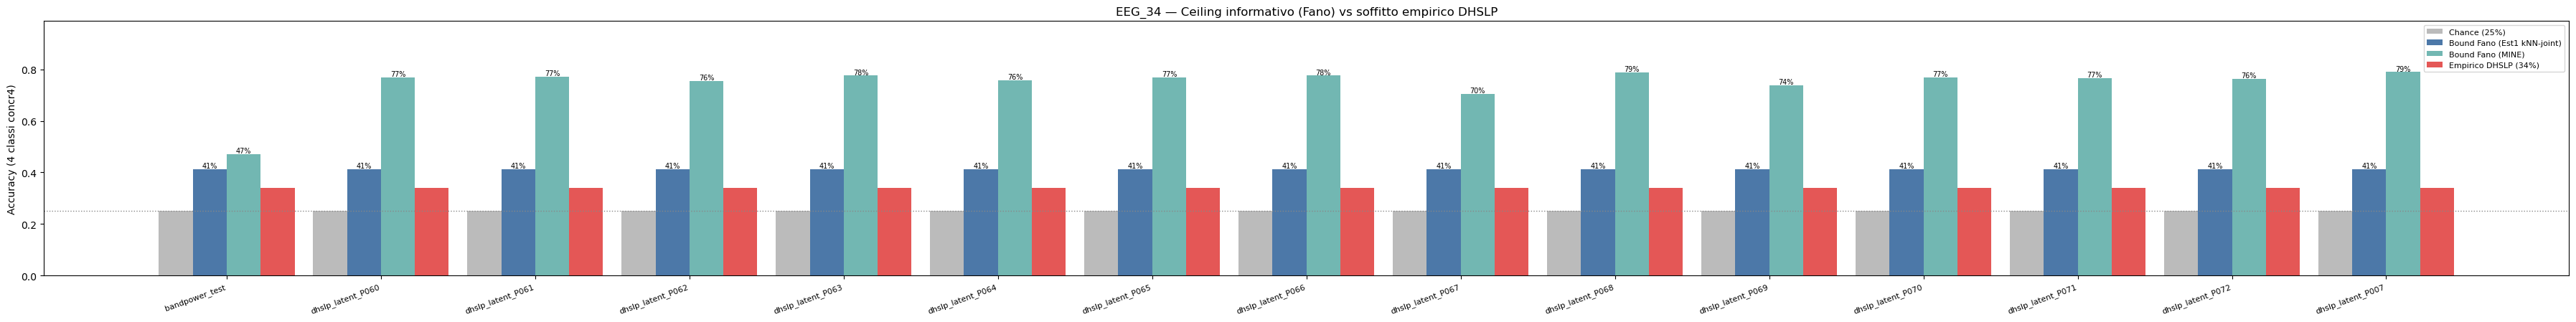

In [12]:
# ---- Plot a barre: chance | bound informativo (Est1-joint, MINE) | empirico ----
fig, ax = plt.subplots(figsize=(max(7, 2.2 * len(ceiling_df) + 3), 4.6))

spaces = ceiling_df.space.tolist()
x = np.arange(len(spaces))
w = 0.22

b_chance = np.full(len(spaces), CHANCE_ACC)
b_est1   = ceiling_df.acc_max_est1_joint.values
b_mine   = ceiling_df.acc_max_mine.values
b_emp    = np.full(len(spaces), EMPIRICAL_ACC)

ax.bar(x - 1.5*w, b_chance, w, label=f'Chance ({CHANCE_ACC:.0%})', color='#bbbbbb')
ax.bar(x - 0.5*w, b_est1,   w, label='Bound Fano (Est1 kNN-joint)', color='#4c78a8')
ax.bar(x + 0.5*w, b_mine,   w, label='Bound Fano (MINE)', color='#72b7b2')
ax.bar(x + 1.5*w, b_emp,    w, label=f'Empirico DHSLP ({EMPIRICAL_ACC:.0%})', color='#e45756')

ax.axhline(CHANCE_ACC, color='#888', ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels(spaces, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Accuracy (4 classi concr4)')
ax.set_ylim(0, max(0.6, np.nanmax([b_est1.max(), b_mine.max(), EMPIRICAL_ACC]) * 1.25))
ax.set_title('EEG_34 — Ceiling informativo (Fano) vs soffitto empirico DHSLP')
ax.legend(fontsize=8, loc='upper right')
for xi, v in zip(x, b_est1):
    if not np.isnan(v): ax.text(xi - 0.5*w, v + 0.005, f'{v:.0%}', ha='center', fontsize=7)
for xi, v in zip(x, b_mine):
    if not np.isnan(v): ax.text(xi + 0.5*w, v + 0.005, f'{v:.0%}', ha='center', fontsize=7)
plt.tight_layout()
out = FIG_DIR / 'eeg34_information_ceiling.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
log.info(f'Figura salvata: {out}')
plt.show()


## §6 — Conclusioni attese / Come leggere i risultati

**Lettura della figura e della tabella `ceiling_df`:**

| Esito | Interpretazione | Conseguenza per la tesi |
|-------|-----------------|--------------------------|
| `acc_max ≈ 34%` (empirico) | Il bound informativo coincide col soffitto DHSLP | **Prova formale: problema *data-limited*.** Non è il modello il limite, è l'informazione presente nel segnale. È il risultato forte: *"abbiamo quantificato il limite informativo e dimostrato di averlo raggiunto"*. |
| `acc_max ≫ 34%` | C'è MI nel segnale che il modello non sfrutta | Esiste **headroom**: vale la pena cercare architetture/preprocessing migliori. Apre una direzione concreta. |
| `acc_max ≈ 25%` (chance) | Quasi nessuna MI estraibile feature↔classe | Coerente con $\varepsilon^2(\text{parola})=0.03$: il segnale è quasi privo di informazione di classe a livello di trial. |

**Confronto tra i due stimatori (robustezza):**
- **Est1 (kNN-joint)** e **MINE** dovrebbero dare bound nello **stesso ordine di grandezza**. MINE è un
  *lower bound*, quindi tipicamente $\le$ Est1-joint; se invece MINE risulta molto più alto, sospettare
  *overfitting* della rete statistica (controllare la curva W&B `mine/.../mi_bits`: deve plateau, non salire indefinitamente).
- La colonna `acc_max_est1_sum_optimistic` (somma additiva) è un **upper bound ottimistico** e va letta solo
  come "tetto teorico al meglio"; la verità sta tra essa e i bound joint/MINE.

**Confronto latente DHSLP vs band-power (controllo):**
- Se $I(\text{latente DHSLP};Y) \approx I(\text{band-power};Y)$ → il modello **non scarta** informazione utile:
  rafforza la tesi *data-limited*.
- Se $I(\text{latente}) \ll I(\text{band-power})$ → il modello **comprime via** informazione: c'è margine
  architetturale (apre direzione).

**Limiti da dichiarare esplicitamente nella tesi:**
1. La MI stimata su **campioni finiti** è rumorosa; per questo riportiamo `±std` su `SEEDS` multipli.
2. **MINE** fornisce un **lower bound** (DV); sottostima $I$ se la rete $T$ è sottodimensionata.
3. La **somma additiva** (Est1-sum) **sovrastima** $I$ congiunto in presenza di feature correlate (EEG lo è).
4. La stima è sul **trial singolo** a 4 classi concr4: il ceiling potrebbe alzarsi aggregando trial
   (averaging) o usando un altro schema di clustering — analisi lasciata a lavoro futuro.
5. Il **bound di Fano** assume un *predittore ottimo*; un classificatore reale può solo avvicinarlo da sotto.

> **In sintesi:** questo notebook converte l'affermazione qualitativa $\varepsilon^2=0.03$ in un **numero in bit**
> e in un **upper bound di accuracy**. Il confronto col 34% empirico decide formalmente se il collo di
> bottiglia è il **dato** (data-limited, ceiling raggiunto) o il **modello** (headroom da sfruttare).
